# EN3160 — Assignment 01

## Intensity Transformations and Neighborhood Filtering

**Deshan W.U.**  
**230130E**

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Question 1

In [20]:
# Import Emma image
emma = cv.imread('images/emma.jpeg', cv.IMREAD_GRAYSCALE)
assert emma is not None

In [21]:
# Define piecewise transformation function
t1 = np.linspace(0, 50, num=51).astype('uint8')
t2 = np.linspace(100, 255, num=100).astype('uint8')
t3 = np.linspace(150, 255, num=105).astype('uint8')

# Concatenate all segments to create the transformation array
t = np.concatenate((t1, t2, t3), axis=0).astype('uint8')
print(t.shape)

(256,)


*Plot the transformation*

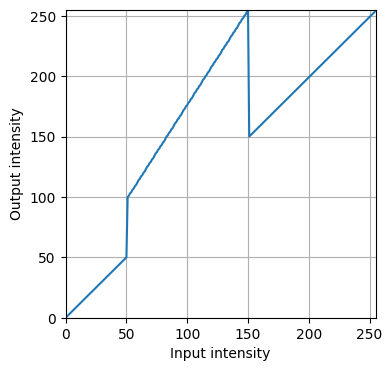

In [23]:
plt.figure(figsize=(4, 4))
plt.plot(t)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.grid(True)
plt.show()

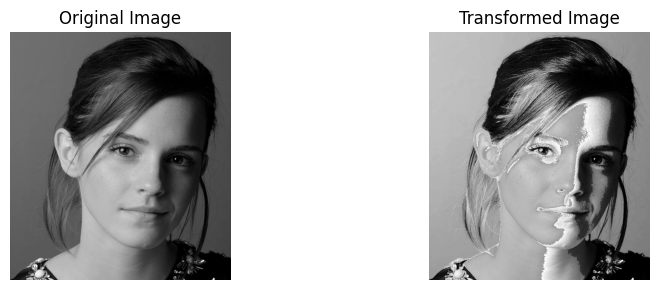

In [25]:
g = t[emma]

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.imshow(emma, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(g, cmap='gray', vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis('off')

plt.tight_layout()
plt.show()

### Question 2

In [26]:
# Import brain image
brain = cv.imread('images/brain.png', cv.IMREAD_GRAYSCALE)
assert brain is not None

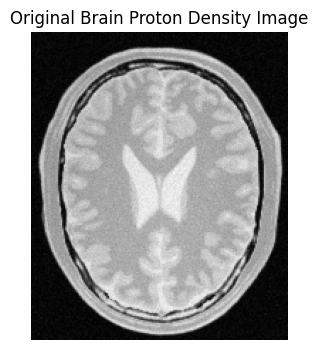

In [27]:
# Display original image
plt.figure(figsize=(4, 4))
plt.imshow(brain, cmap='gray', vmin=0, vmax=255)
plt.title("Original Brain Proton Density Image")
plt.axis("off")
plt.show()

a) white matter

(256,)


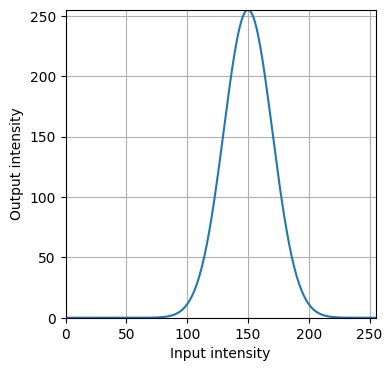

In [29]:
# Define the gaussian pulse
mu = 150
sigma = 20
x = np.linspace(0, 255, 256)
t = 255 * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Ensure the output is in the valid range for image intensities [0, 255]
t = np.clip(t, 0, 255)

print(t.shape)

# Plot the array
plt.figure(figsize=(4, 4))
plt.plot(t)
plt.xlabel("Input intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.ylabel("Output intensity")
plt.grid(True)
plt.show()

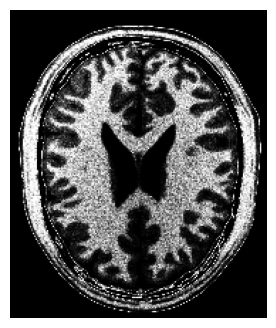

In [30]:
g = t[brain]

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(g, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

b) gray matter

(256,)


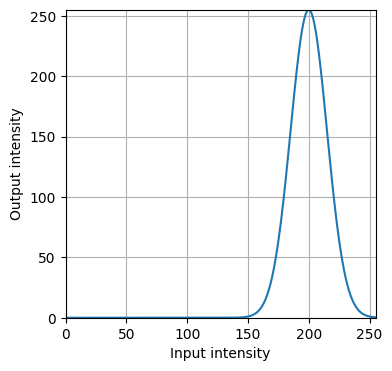

In [31]:
mu = 200
sigma = 15
x = np.linspace(0, 255, 256)
t = 255 * np.exp(-((x - mu)**2) / (2 * sigma**2))

# Ensure the output is in the valid range for image intensities [0, 255]
t = np.clip(t, 0, 255)

print(t.shape)

# Plot the array
plt.figure(figsize=(4, 4))
plt.plot(t)
plt.xlabel("Input intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.ylabel("Output intensity")
plt.grid(True)
plt.show()

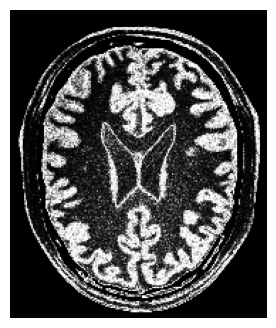

In [32]:
# Apply transformation
g = t[brain]

# Display transformed image
plt.figure(figsize=(4, 4))
plt.imshow(g, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### Question 3

In [34]:
# Import  image
girl = cv.imread('images/girl.jpeg')
assert girl is not None

In [35]:
lab = cv.cvtColor(girl, cv.COLOR_BGR2LAB)
girl_rgb = cv.cvtColor(girl, cv.COLOR_BGR2RGB)
L, a, b = cv.split(lab)
L_norm = L.astype(np.float32) / 255.0

In [36]:
#Apply gamma correction
gamma = 0.75
L_corrected = np.power(L_norm, gamma)
L_corrected = np.clip(L_corrected * 255,0,255).astype(np.uint8)
lab_corrected = lab.copy()
lab_corrected[:, :, 0] = L_corrected
rgb_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2RGB)

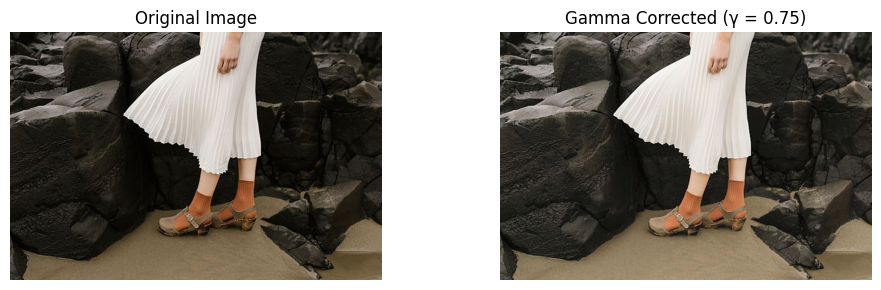

In [37]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.imshow(girl_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rgb_corrected)
plt.title(f"Gamma Corrected (γ = {gamma})")
plt.axis("off")

plt.tight_layout()
plt.show()

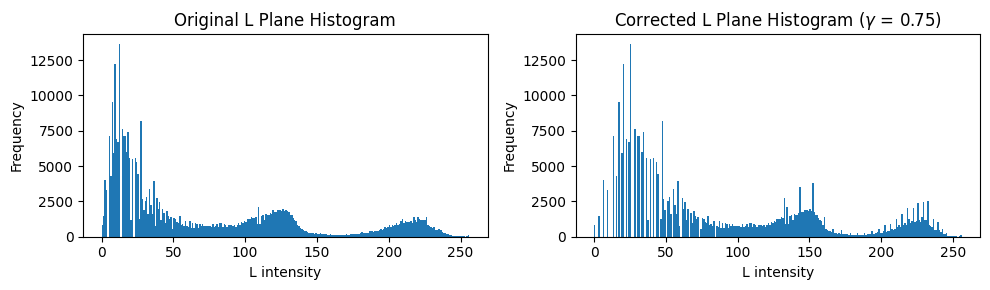

In [38]:
# Histograms of L plane before and after gamma correction

plt.figure(figsize=(10, 3))

# Original L plane histogram
plt.subplot(1, 2, 1)

plt.hist(
    L.ravel(),
    bins=256,
    range=(0, 256)
)

plt.xlabel("L intensity")
plt.ylabel("Frequency")
plt.title("Original L Plane Histogram")


# L plane histogram after gamma correction
plt.subplot(1, 2, 2)

plt.hist(
    L_corrected.ravel(),
    bins=256,
    range=(0, 256)
)

plt.xlabel("L intensity")
plt.ylabel("Frequency")
plt.title(f"Corrected L Plane Histogram ($\\gamma$ = {gamma})")

plt.tight_layout()
plt.show()

### Question 4

In [39]:
# Import image
peter = cv.imread('images/peter.png')
assert peter is not None
peter_hsv = cv.cvtColor(peter, cv.COLOR_BGR2HSV)
peter_rgb = cv.cvtColor(peter, cv.COLOR_BGR2RGB)

# Split into planes
H, S, V = cv.split(peter_hsv)

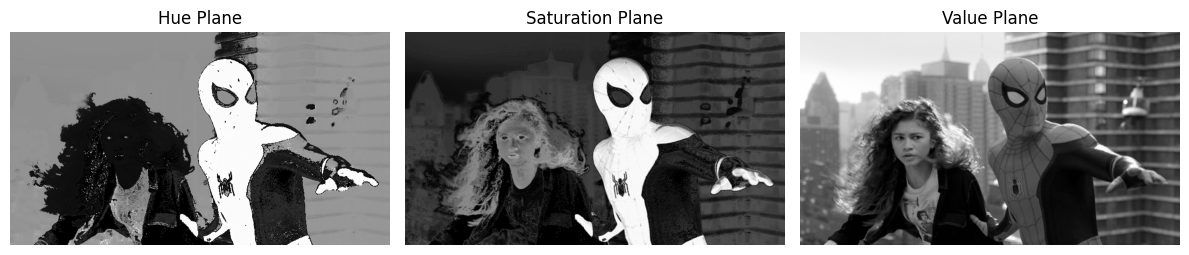

In [40]:
# Display the planes
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(H, cmap='gray')
axs[0].set_title('Hue Plane')
axs[0].axis('off')

axs[1].imshow(S, cmap='gray')
axs[1].set_title('Saturation Plane')
axs[1].axis('off')

axs[2].imshow(V, cmap='gray')
axs[2].set_title('Value Plane')
axs[2].axis('off')

plt.tight_layout()
plt.show()

In [43]:
# Define the transformation function
a = 0.7
sigma = 70.0 
x = np.arange(0, 256)
f = np.minimum(x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)), 255).astype('uint8')

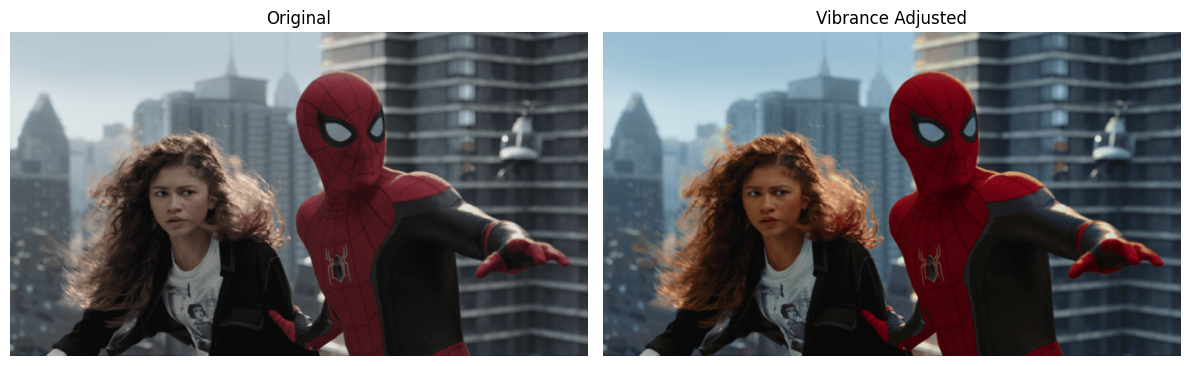

In [44]:
# Apply transformation to Saturation plane
S_modified = cv.LUT(S, f)

# Merge H, modified S, and V planes
merged = cv.merge([H, S_modified, V])

# Convert HSV to RGB
peter_modified = cv.cvtColor(merged, cv.COLOR_HSV2RGB)

# Create a figure and axes
fig, axs = plt.subplots(1, 2, figsize=(12, 8))

# Original image
axs[0].imshow(peter_rgb)
axs[0].set_title('Original')
axs[0].axis('off')

# Saturation-adjusted image
axs[1].imshow(peter_modified)
axs[1].set_title('Vibrance Adjusted')
axs[1].axis('off')

# Show the plot
plt.tight_layout()
plt.show()

By fine-tuning the parameter a, several values were tested to obtain a visually pleasing output. After comparing the resulting images, a = 0.6 was selected as the best value. This value provided an appropriate enhancement of the image saturation while maintaining a natural appearance.

### Question 5

In [6]:
# Import Shells image
beans = cv.imread('images/beans.png', cv.IMREAD_GRAYSCALE)
assert beans is not None

In [8]:
def histogram_equalization(f):
    # Get image details
    L = 256
    M, N = f.shape

    # Get histogram
    hist = cv.calcHist([f], [0], None, [L], [0, L])
    cdf = hist.cumsum()

    # Define transformation
    t = np.array([(L-1)/(M*N)*cdf[k] for k in range(256)]).astype("uint8")

    return t[f]

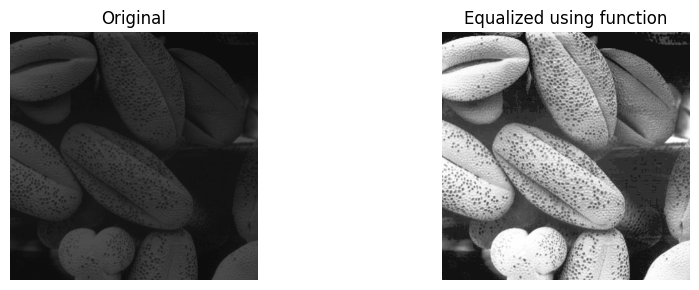

In [18]:
# Do histrogram equalization
equalized = histogram_equalization(beans)

# Create the figure for plotting
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].imshow(beans, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original')
ax[0].axis("off")
ax[1].imshow(equalized, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Equalized using function')
ax[1].axis("off")

# Show the plot
plt.tight_layout()
plt.show()

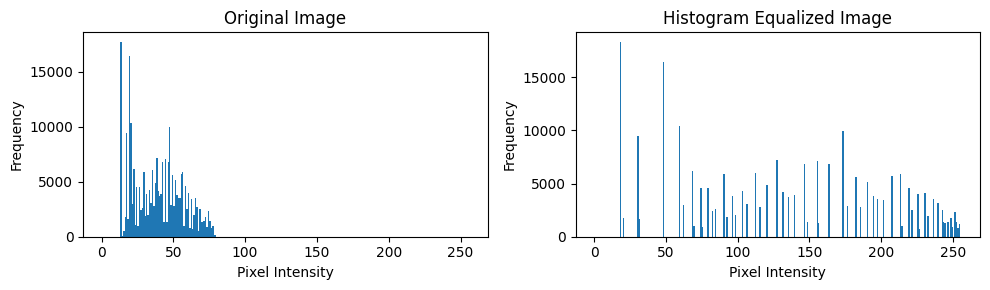

In [17]:
# Display histograms
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].hist(beans.ravel(), bins=256, range=(0, 256))
ax[0].set_title('Original Image')
ax[0].set_xlabel('Pixel Intensity')
ax[0].set_ylabel('Frequency')

ax[1].hist(equalized.ravel(), bins=256, range=(0, 256))
ax[1].set_title('Histogram Equalized Image')
ax[1].set_xlabel('Pixel Intensity')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Question 6

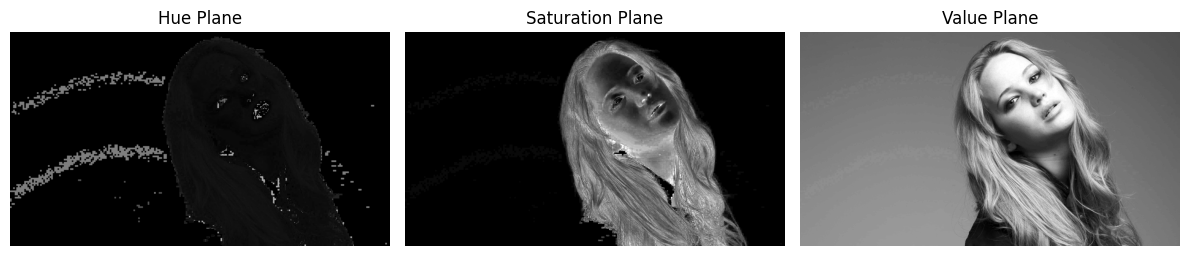

In [47]:
# a)
#  Read the image
jennifer = cv.imread('images/jennifer.jpeg')
assert jennifer is not None

# Convert BGR image to HSV
hsv = cv.cvtColor(jennifer, cv.COLOR_BGR2HSV)

# Split HSV into three planes
H, S, V = cv.split(hsv)

# Display H, S and V planes in grayscale
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap='gray' ,vmin=0, vmax=255)
plt.title('Hue Plane')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(S, cmap='gray' ,vmin=0, vmax=255)
plt.title('Saturation Plane')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(V, cmap='gray' ,vmin=0, vmax=255)
plt.title('Value Plane')
plt.axis('off')

plt.tight_layout()
plt.show()

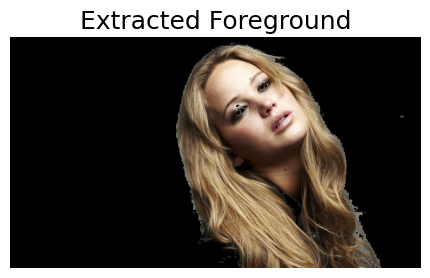

In [48]:
# b) Apply thresholding on Saturation plane
_, mask = cv.threshold(S, 12, 255, cv.THRESH_BINARY)

# Use bitwise_and to extract the foreground using the mask
foreground = cv.bitwise_and(jennifer, jennifer, mask=mask)

# Display the extracted foreground
plt.figure(figsize=(10, 3))

plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
plt.title('Extracted Foreground', fontsize=18)
plt.axis('off')
plt.show()

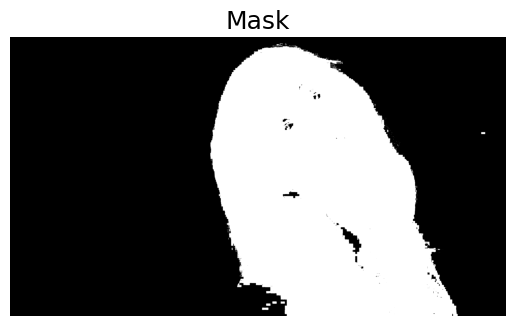

In [49]:
# c)
plt.imshow(mask, cmap='gray')
plt.title('Mask', fontsize=18)
plt.axis('off')
plt.show()

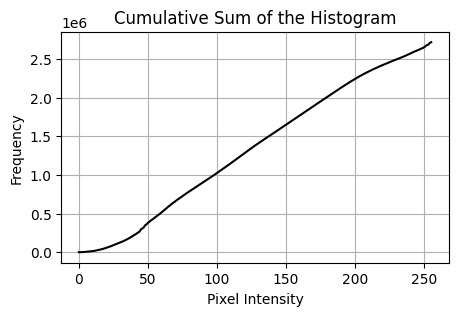

In [77]:
# d) Calculate the cumulative sum of the histogram
hist = cv.calcHist([V], [0], mask, [256], [0, 256])
cdf = hist.cumsum()

# Plot the histogram
plt.figure(figsize=(5, 3))
plt.plot(cdf, color='black')
plt.title('Cumulative Sum of the Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

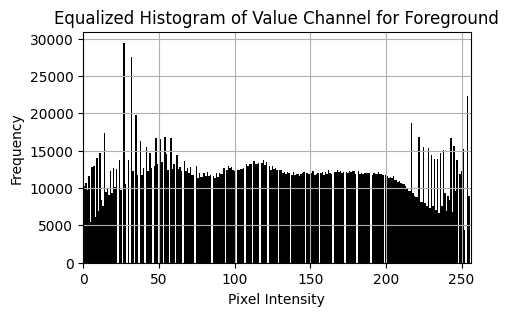

In [78]:
# e) Calculate the histogram of the Value channel
# Number of pixels
pixels = cdf[-1]

# Define transformation
t = np.array([(256-1)/(pixels)*cdf[k] for k in range(256)]).astype("uint8")

# Equalize
V_eq = t[V]

# Calculate the histogram of the equalized Value channel
hist = cv.calcHist([V_eq], [0], mask, [256], [0, 256])

# Create an array for the x positions of the bars
x_positions = np.arange(len(hist))

# Plot the histogram as a bar plot
plt.figure(figsize=(5, 3))
plt.bar(x_positions, hist.flatten(), color='black', width=1) 
plt.title('Equalized Histogram of Value Channel for Foreground')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256]) 
plt.grid(True)
plt.show()

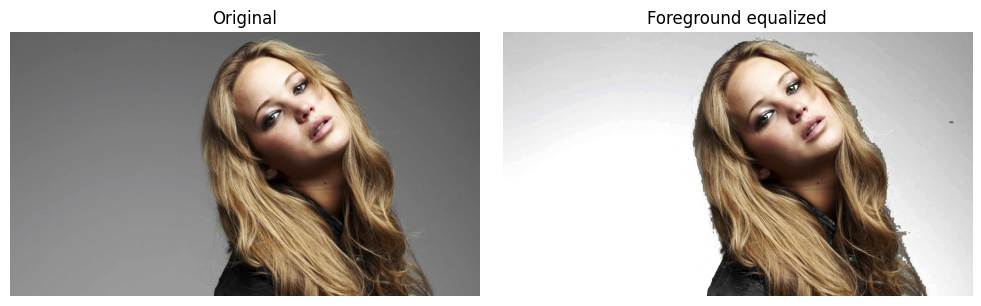

In [75]:
# Merge
merged = cv.merge([H, S, V])
foreground_modified = cv.cvtColor(merged, cv.COLOR_HSV2RGB)
# Extract the background
background = cv.bitwise_and(jennifer, jennifer, mask=cv.bitwise_not(mask))

# Merge the equalized foreground and background
result = cv.add(cv.cvtColor(background, cv.COLOR_BGR2RGB), foreground_modified)

# Create a figure and axes
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

# Plot images
axs[0].imshow(cv.cvtColor(jennifer, cv.COLOR_BGR2RGB))
axs[0].set_title('Original')
axs[0].axis('off') 
axs[1].imshow(result)
axs[1].set_title('Foreground equalized')
axs[1].axis('off') 

plt.tight_layout()
plt.show()

### Question 7

In [79]:
# Import Einstein image
albert = cv.imread('images/albert.png', cv.IMREAD_GRAYSCALE)
assert albert is not None

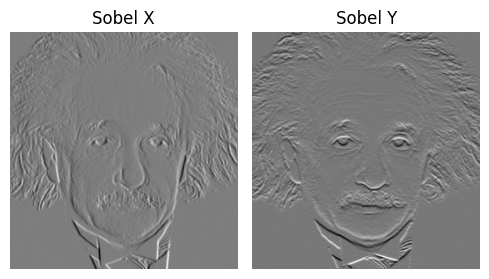

In [96]:
# a) Define the Sobel-X filter
sobel_x = np.array([[1, 0, -1], 
                    [2, 0, -2], 
                    [1, 0, -1]])

# Define the Sobel-Y filter
sobel_y = np.array([[1, 2, 1], 
                    [0, 0, 0], 
                    [-1, -2, -1]])
# Apply the Sobel filter in the X direction
sobel_x_filtered = cv.filter2D(albert, cv.CV_64F, sobel_x)

# Apply the Sobel filter in the Y direction
sobel_y_filtered = cv.filter2D(albert, cv.CV_64F, sobel_y)

# Display both
plt.figure(figsize=(5, 3))

plt.subplot(1, 2, 1)
plt.imshow(sobel_x_filtered, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sobel_y_filtered, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.tight_layout()
plt.show()

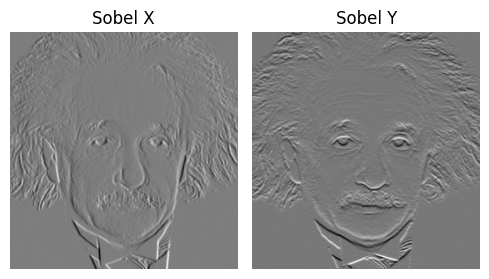

In [95]:
# b)
def apply_filter(image, filter):
    [rows, columns] = np.shape(image)
    filtered_image = np.zeros(shape=(rows, columns))

    for i in range(rows - 2):
        for j in range(columns - 2):

            # Apply 3x3 convolution
            value = np.sum(
                np.multiply(filter, image[i:i + 3, j:j + 3])
            )

            filtered_image[i + 1, j + 1] = value

    return filtered_image


# Sobel X filter
sobel_x = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
])

# Sobel Y filter
sobel_y = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
])


# Apply the Sobel filter in the X direction
sobel_x_filtered = cv.filter2D(albert, cv.CV_64F, sobel_x)

# Apply the Sobel filter in the Y direction
sobel_y_filtered = cv.filter2D(albert, cv.CV_64F, sobel_y)

# Display Sobel X and Y
plt.figure(figsize=(5, 3))
plt.subplot(1, 2, 1)
plt.imshow(sobel_x_filtered, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sobel_y_filtered, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.tight_layout()
plt.show()

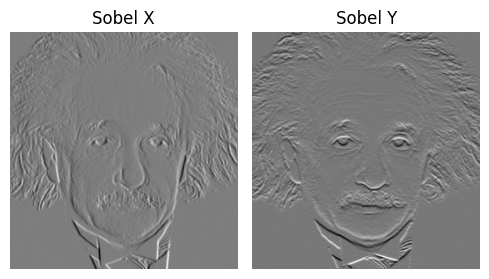

In [94]:
#c) Separated Sobel filters
sobel_x_v = np.array([[1], [2], [1]])
sobel_x_h = np.array([[1, 0, -1]])

sobel_y_v = np.array([[1], [0], [-1]])
sobel_y_h = np.array([[1, 2, 1]])

# Apply separable filters
x_filtered = cv.filter2D(
    cv.filter2D(albert, cv.CV_64F, sobel_x_h),
    cv.CV_64F, sobel_x_v
)

y_filtered = cv.filter2D(
    cv.filter2D(albert, cv.CV_64F, sobel_y_v),
    cv.CV_64F, sobel_y_h
)

# Display results
plt.figure(figsize=(5, 3))
plt.subplot(1, 2, 1)
plt.imshow(x_filtered, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(y_filtered, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.tight_layout()
plt.show()

## Question 8